# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [43]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Write your code here to read the data
path = '/content/drive/MyDrive/foodhub_order.csv'
df = pd.read_csv(path)

In [6]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the

*   List item
*   List item

data? [0.5 mark]

In [7]:
# Write your code here
df.shape

(1898, 9)

#### Observations:
There are 1898 rows and 9 columns.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [8]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


### Observations
There are no null values in the dataset. There are 4 columns of integer datatype, 4 columns that are of String/object data type and one column of float data type.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [9]:
# Write your code here
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
There are no missing values in the dataset. However, there are 'Not given' values for rating which implies missing ratings for orders.

This can be treated by creating a new column for rating of int data type and the 'Not given' values can be replaced with 0 or NaN using the replace function.Use the astype function to convert the column data type to int or float.

df['rating_int'] = df['rating'].replace('Not given',0)

df['rating_int'].astype('int')


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [10]:
# Write your code here
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0



#### Observations:
The miminum time taken to prepare food after an order got placed is 20mins.
The average time taken to prepare food after an order got placed is 27.37mins.
The maximum time taken to prepare food after an order got placed is 35 mins.


### **Question 5:** How many orders are not rated? [1 mark]

In [11]:
# Write the code here
condition = df['rating']=='Not given'
df[condition].rating.count()

np.int64(736)

#### Observations:
There are 736 orders that are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [12]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [13]:
# Write the code here
#find the number of unique order Ids
df['order_id'].nunique()


1898

###Observations
All the order ids in the given dataset are unique and there are a total of 1898 unqiue order Ids.

# **Customer ID**

In [14]:
#Number of unique customer id.

df['customer_id'].nunique()

1200

###Observations
There are 1200 unique customer IDs in the dataset.

# **Restaurant Name**

In [15]:
#unique restaurants
df['restaurant_name'].nunique()

178

#### Observations:
There are 178 unique restaurant names out of 1898 entries.

# **Cuisine Type**

In [16]:
df['cuisine_type'].nunique()

14

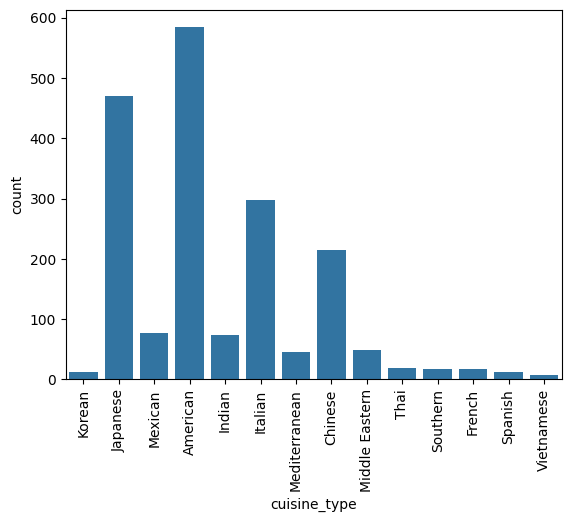

In [17]:
sns.countplot(x='cuisine_type',data=df)
plt.xticks(rotation=90)
plt.show()

###Observations
There are 178 unique cuisines in the dataset.
American is the most preferred or popular  cuisine type followed by Japanese, Italian and Chinese. The least popular cuisine type is vietnamese.

# **Day of the week**

In [18]:
df['day_of_the_week'].nunique()

2

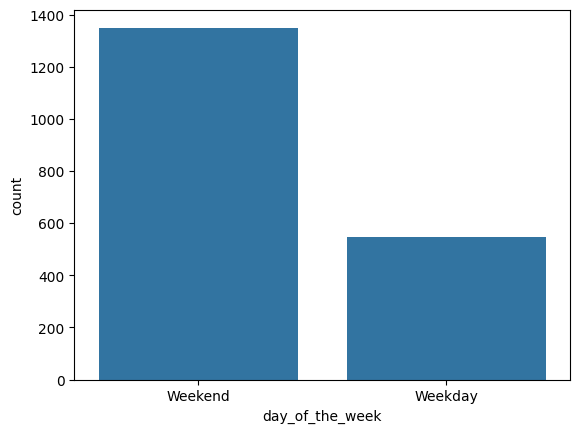

In [19]:
sns.countplot(x='day_of_the_week',data=df)
plt.show()

###Observations
The data is categorized by weekday and weekend for the day_of_the_week.
The plot shows that are more orders placed on weekend compared to the number of orders during weekday.

# **Rating**

In [20]:
df['rating'].nunique()

4

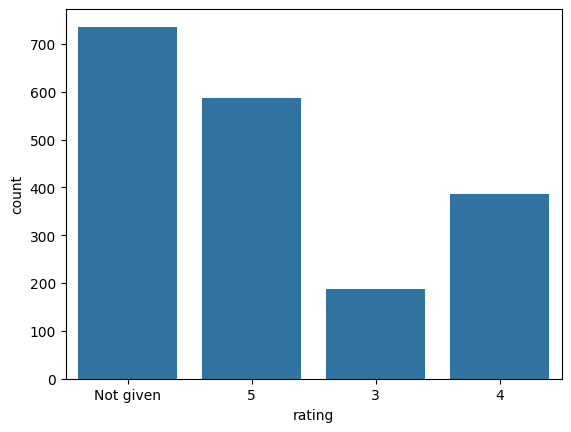

In [21]:
sns.countplot(x='rating',data=df)
plt.show()

###Observations
Many orders approximatley 730 are not rated. The rest of the orders are given a rating of 3,4,5. The rating with the most number of orders is 5.The rating with the least number of orders is 3.

# **Cost of the Order**

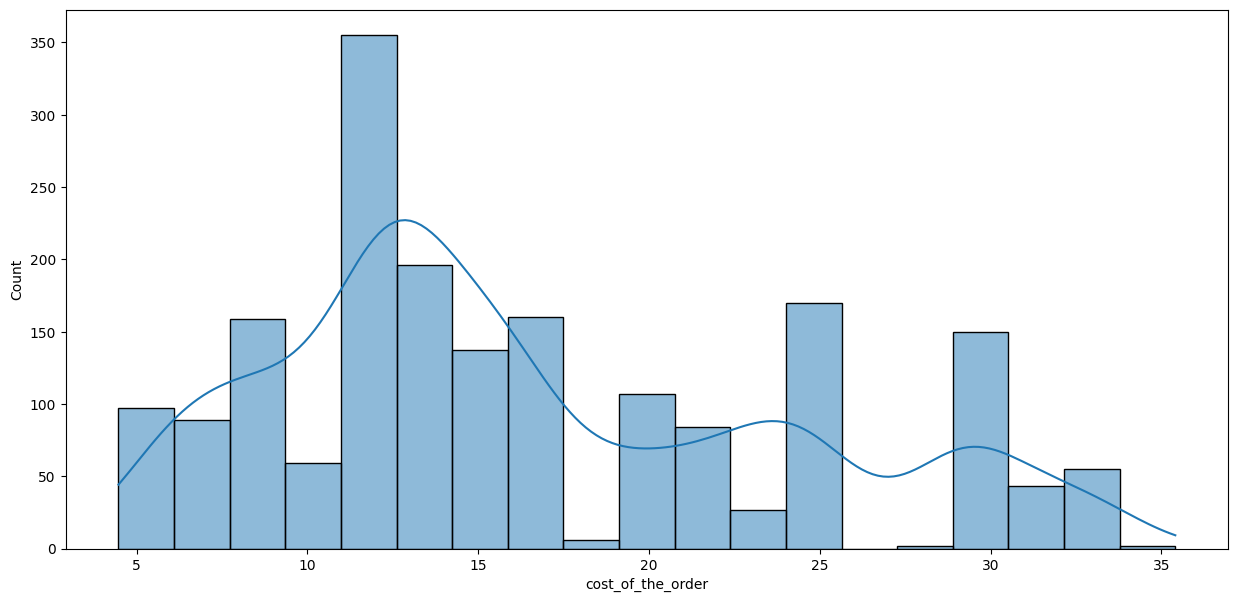

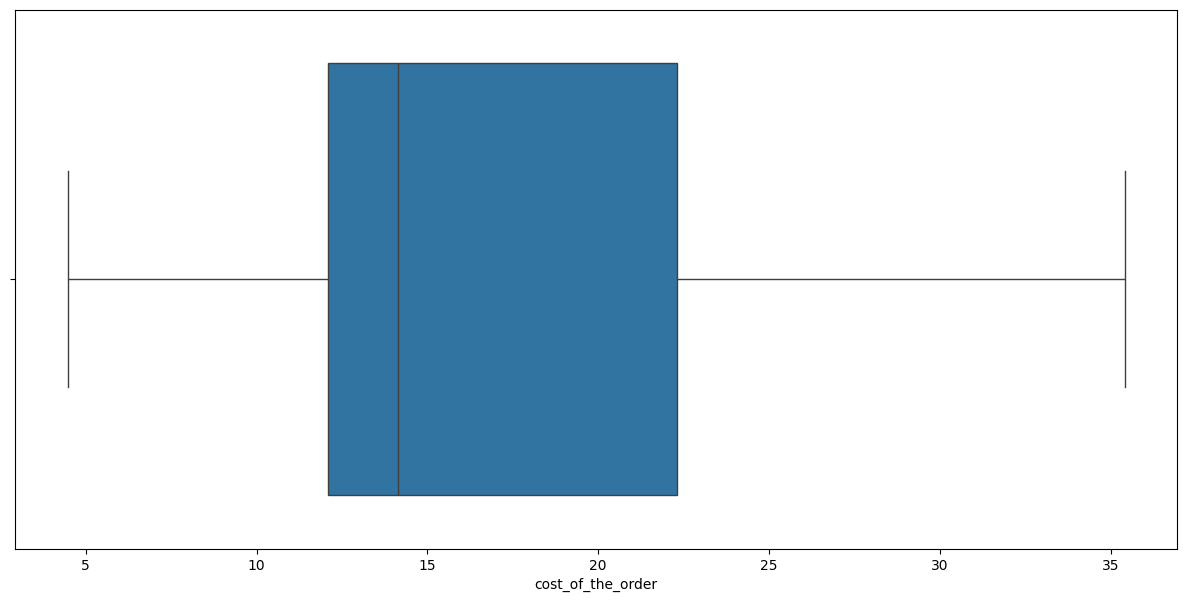

In [22]:
plt.figure(figsize=(15,7))
sns.histplot(x='cost_of_the_order',data=df,kde=True)
plt.show()

plt.figure(figsize=(15,7))
sns.boxplot(x='cost_of_the_order',data=df)
plt.show()



### Observations

Histplot:
The cost of the orders ranges between $5 to $35.There is a peak seen between $11-$13.The data seems to be positively skewed with a longer tail to the right.

Barplot:
The minimum cost of order is 5 dollars and the maximum cost of order is 36 dollars.
The median cost of order is around 14 dollars.
The right whisker is longer than the left and the median is less than mean indicating a right skew.



# **Food Preparation Time**

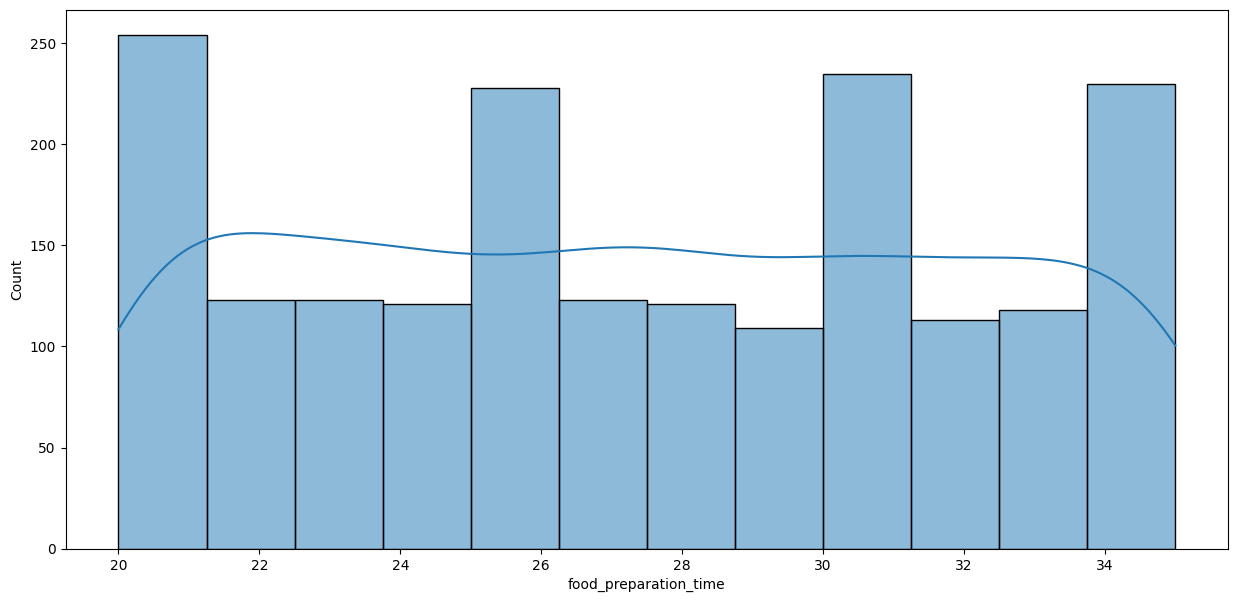

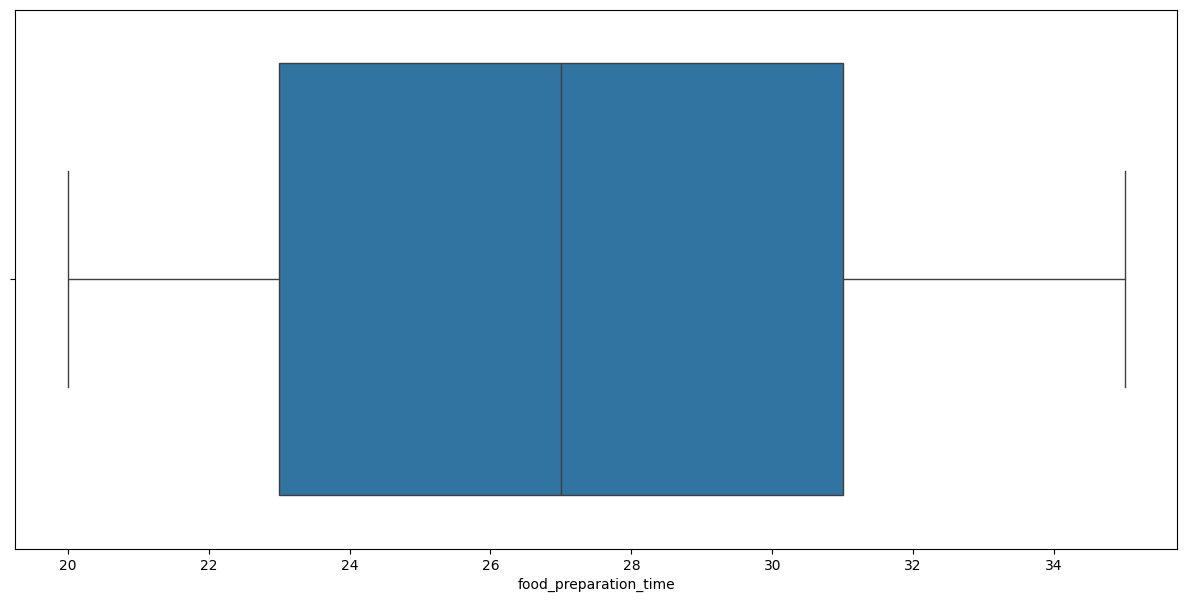

In [23]:
plt.figure(figsize=(15,7))
sns.histplot(x='food_preparation_time',data=df,kde=True)
plt.show()

plt.figure(figsize=(15,7))
sns.boxplot(x='food_preparation_time',data=df)
plt.show()

### Observations:
Histplot:
The food preparation time ranges between 20-35 mins.There are peaks at regular interval of 20, 25,30 and 35 mins.

The data is not normally distributed but has some peaks.

Boxplot:
The median food prepation time is 27 mins. The data distribution is symmetric and the whiskers are almost of the same length. There are no visible outliers and no significant skew in the data.



# **Delivery Time**

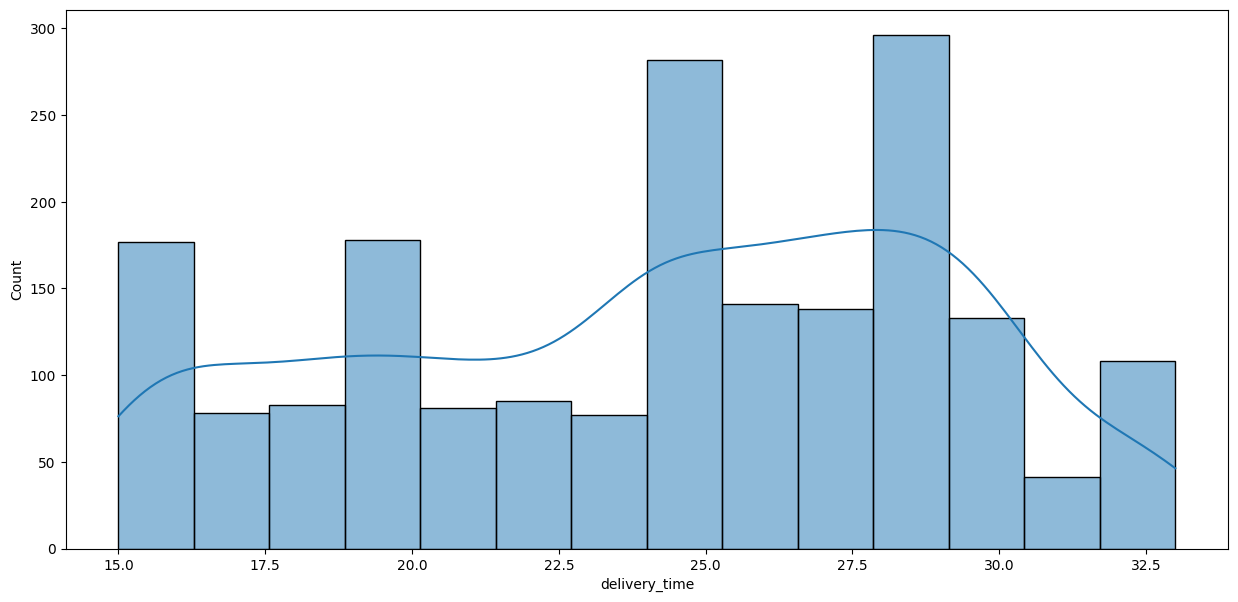

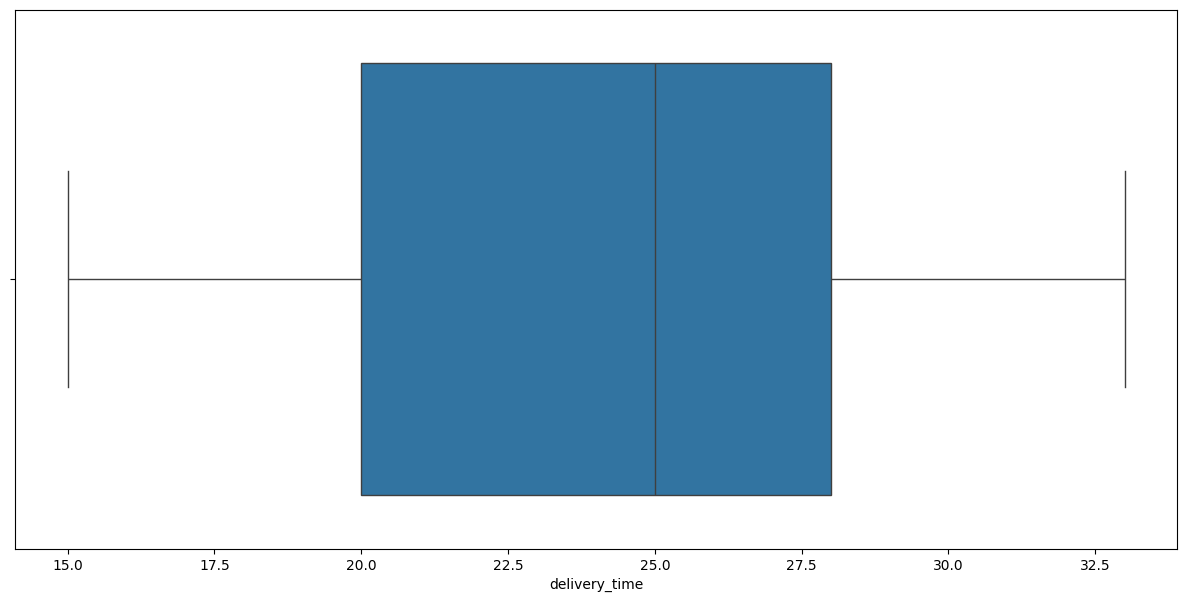

In [24]:
plt.figure(figsize=(15,7))
sns.histplot(x='delivery_time',data=df,kde=True)
plt.show()

plt.figure(figsize=(15,7))
sns.boxplot(x='delivery_time',data=df)
plt.show()

###Observations
Histplot:
The delivery time ranged from 15mins - 33mins. There are some peaks seen at 15,20,25 and 29 mins. There is a slight skew to the left in the data.
Boxplot:
The median delivery time is 25 mins and The IQR is between 20-28 mins. 50% of the orders are delivered in less than 25 mins.
There are no visible outliers. The median is slightly towards the right and the mean is less than median indicating a mild left skew.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [25]:

order_count = df.groupby(['restaurant_name'])['order_id'].count()
order_count.sort_values(ascending=False).head()

,order_id
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
The following are the top 5 restaurants in terms of the number of orders received.Shake Shack tops the list with 219 orders.

```markdown
**Restaurant Name         | Total Orders Received**
--------------------------|-----------------------
Shake Shack               | 219
The Meatball Shop         | 132
Blue Ribbon Sushi         | 119
Blue Ribbon Fried Chicken | 96
Parm                      | 68

```

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [26]:
# Write the code here
df[df['day_of_the_week']=='Weekend'].cuisine_type.value_counts()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


#### Observations:
The most popular cuisine type on weekends is American with a total weekend order count of 415.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [27]:
# Write the code here
df.head()
df_orders = df[df['cost_of_the_order']>20]
order_percent = df_orders['cost_of_the_order'].count()*100/len(df)
order_percent


np.float64(29.24130663856691)

#### Observations:
29.24 percentage of the orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [28]:
# Write the code here

df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:
The mean order delivery time is 24.16 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [29]:
# Write the code here
df['customer_id'].value_counts()

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
...,...
143926,1
89574,1
157711,1


#### Observations:
The top three IDs of the most frequent customers are:

```markdown
**ID          | Total number of orders**
--------------|------------------
52832         | 13
47440         | 10
83287         | 9

```

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


## **Cuisine Type vs Cost of the Order**

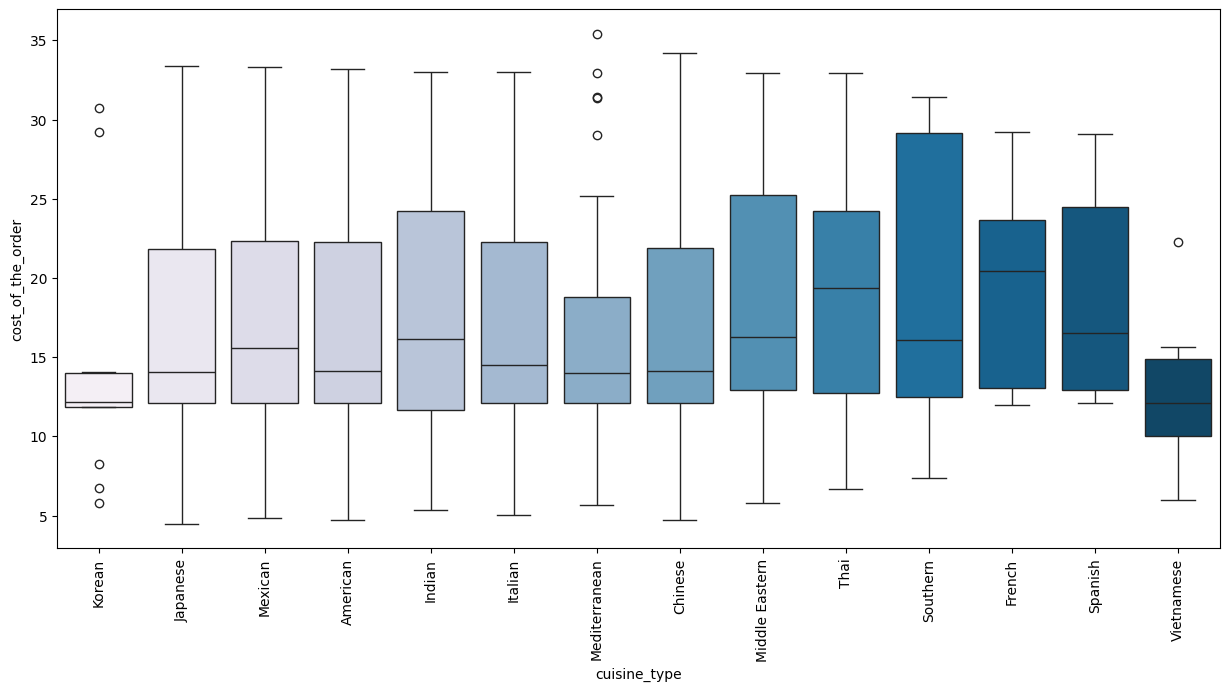

In [30]:
plt.figure(figsize=(15,7))
sns.boxplot(x='cuisine_type',y='cost_of_the_order',data=df,palette = 'PuBu', hue = "cuisine_type")
plt.xticks(rotation=90)
plt.show()

### Observation:
* Except Southern Cuisine, 75% of all the other cuisine types costs less than $25.

* Southern cuisine has the largest IQR which indicates more variability in the price of the orders. While Korean and vietnamese have comparitively smaller IQR indicating more consistance price of the orders.

* The median cost of all the cuisine types are less than $20.

* The median price of vietnamese and Korean are the lowest at around $12 indicating these cuisines are more budget friendly.

* French and Thai cuisines have higher medians indicating that customers place expensive orders for these cuisines.

* Outliers in Mediterranean indicates some premium orders.Korean has few low end and high end orders as well.




## **Cuisine Type vs Food Preparation Time**

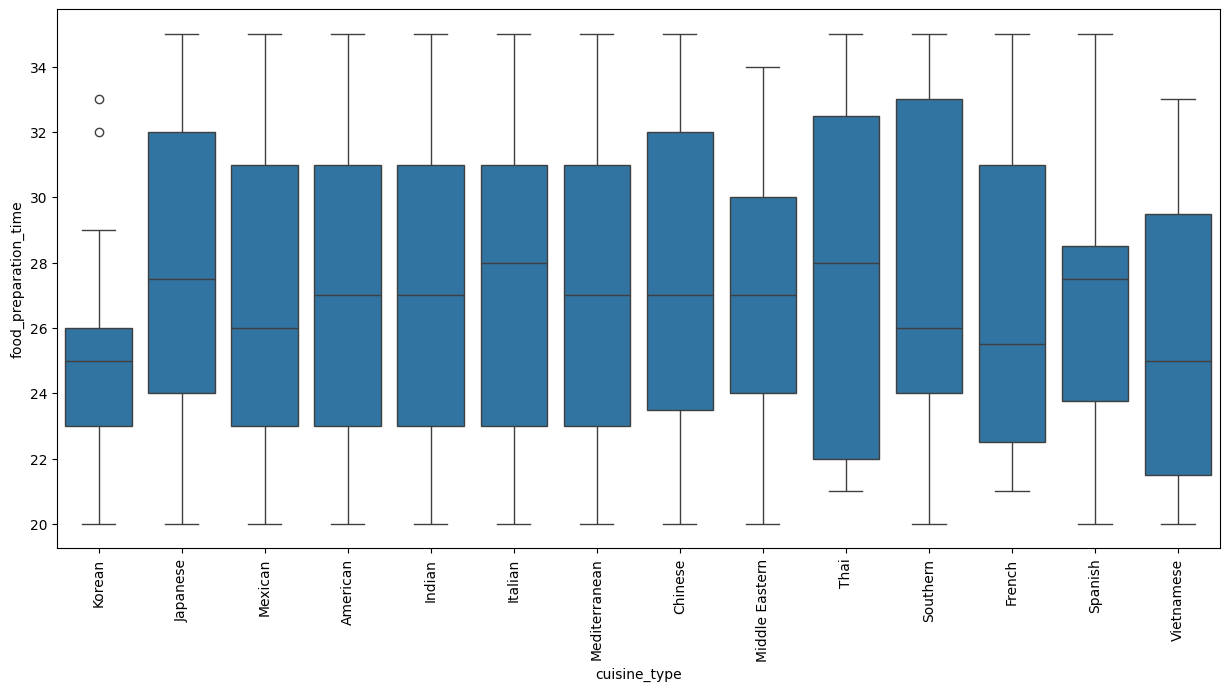

In [31]:
plt.figure(figsize=(15,7))
sns.boxplot(x='cuisine_type',y='food_preparation_time',data=df)
plt.xticks(rotation=90)
plt.show()

### Observation

* Korean cuisine has the least median cooking time around 25 mins.

* Korean and Spanish have smaller IQR indicating less variation of cooking time across their orders.

* Thai and Southern cuisine have a larger spread indicating more variability in their cooking time.

* Most of the cuisines have median cooking time ranging between 26-28 mins and IQRs are fairly wide indicating moderate variation in cooking time.


## **Day of the Week vs  Delivery Time**

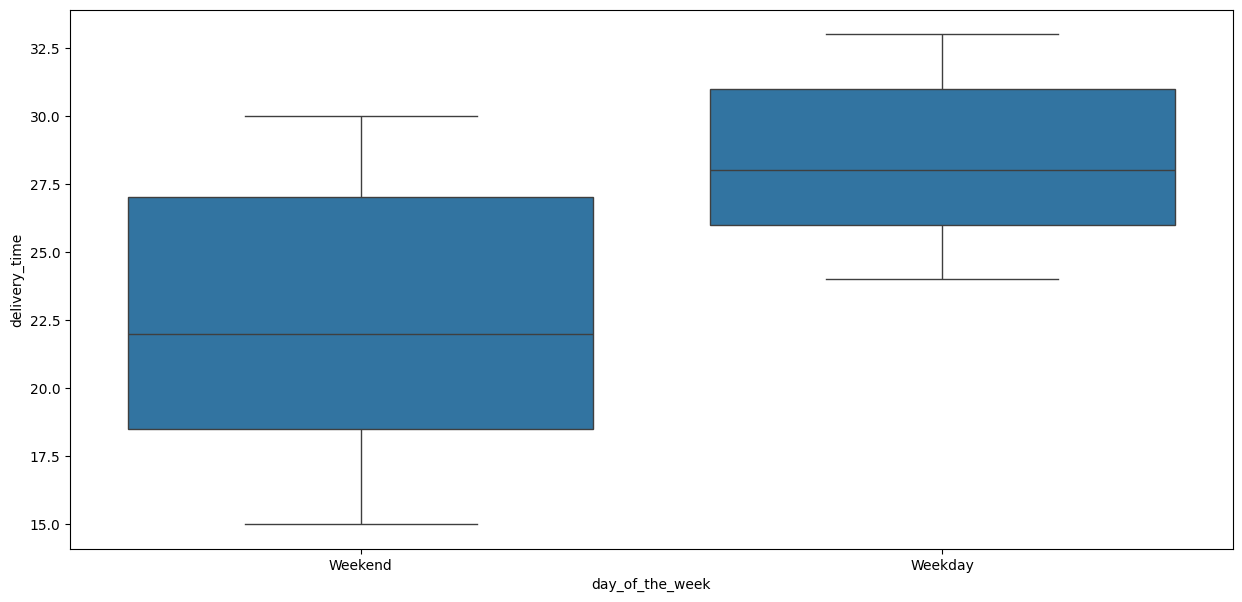

In [32]:
plt.figure(figsize=(15,7))
sns.boxplot(x='day_of_the_week',y='delivery_time',data=df)
plt.show()


###Observations
* The delivery time during weekdays are longer than weekends.
* The mean delivery time on weekend is arround 22.5 and is lower than the average delivery time during weekday which is around 27.8 mins.
* The IQR for Weekend is larger between 17.8 mins to 27.3 mins indicating more variability in the delivery time.
* IQR for weekday is between 27.2 mins to 31 mins indicating more consistantly longer delivery times.


## **Rating vs Food preparation time**

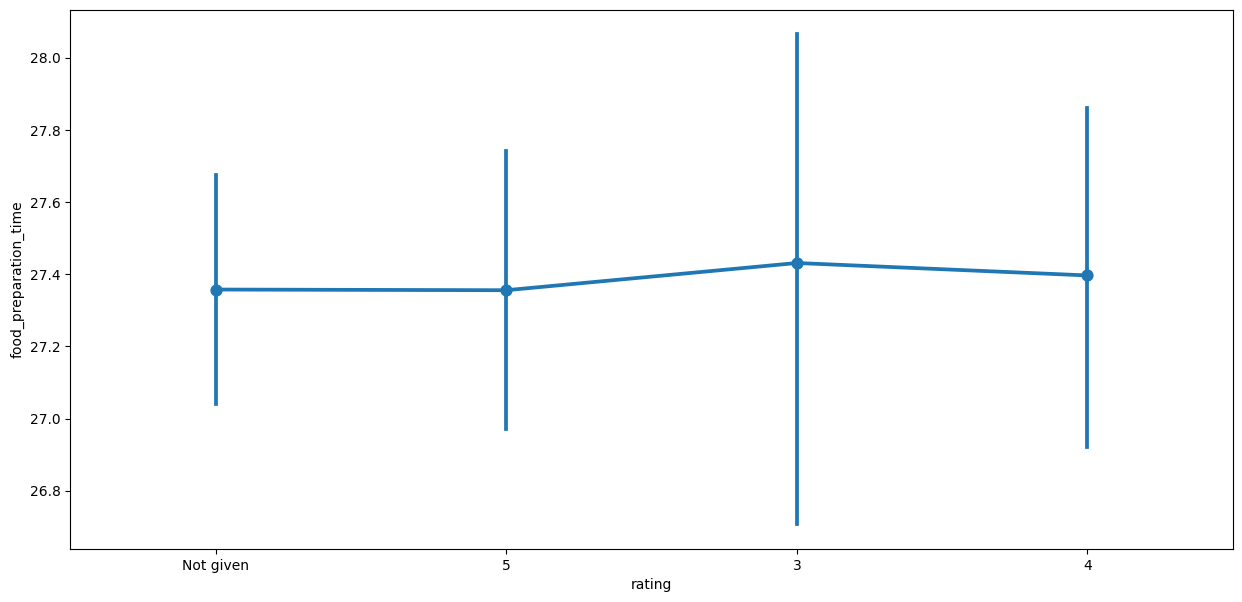

In [33]:
plt.figure(figsize=(15,7))
sns.pointplot(x='rating',y='food_preparation_time',data=df)
plt.show()

###Observations

* The mean food preparation time is almost similar across different ratings. The mean time is approximately between 27.30 to 27.40 mins.
* The standard deviation or variability of mean time is higher for rating 3 indicating several orders with varying preparation time.
* The plot shows the the food preparation time does not affect the rating.


## **Rating vs Delivery Time**

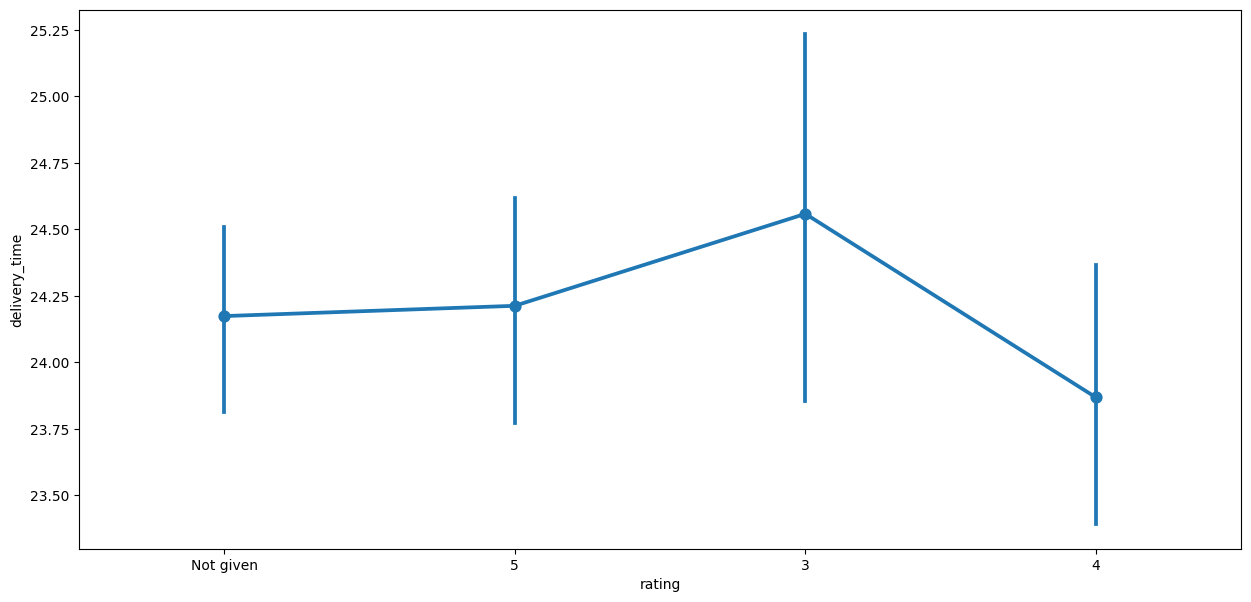

In [34]:
plt.figure(figsize=(15,7))
sns.pointplot(x='rating',y='delivery_time',data=df)
plt.show()

###Observations
* The average delivery time is highest around 24.5 mins for orders that have a rating of 3 with more variability or deviation which indicates less consistent delivery times across those orders.

* The average delivery time is the lowest for orders that have a rating of 4 at around 23.85 mins.

* Delivery time seems to have some impact on the rating.Orders with longer delivery times and higher variability have lower rating.


## **Rating vs Cost of order**

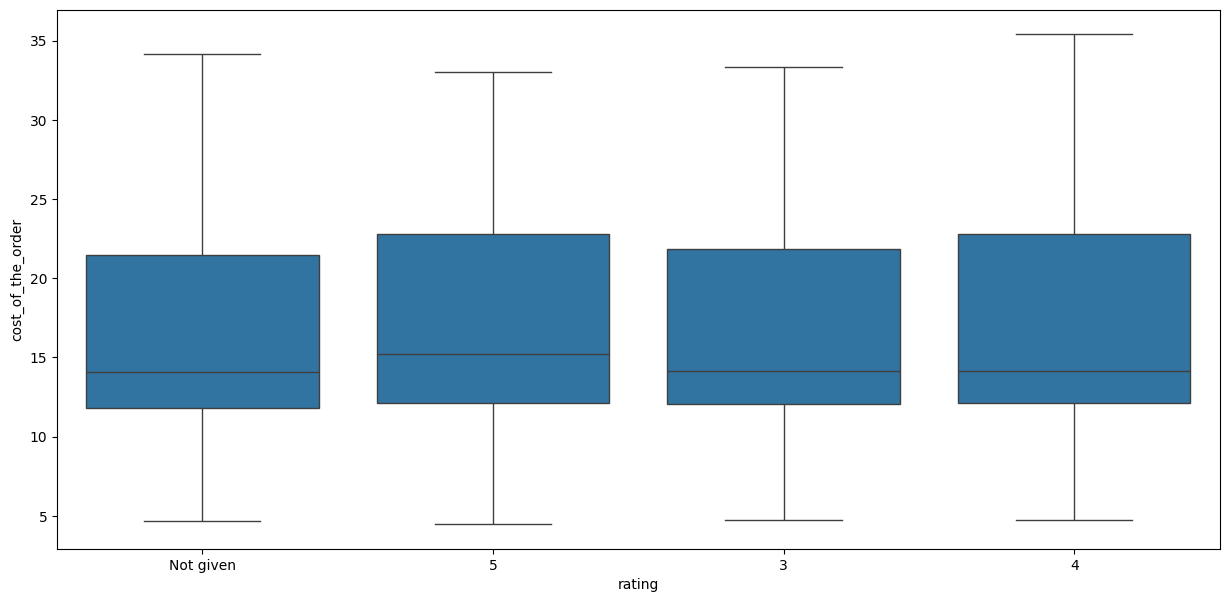

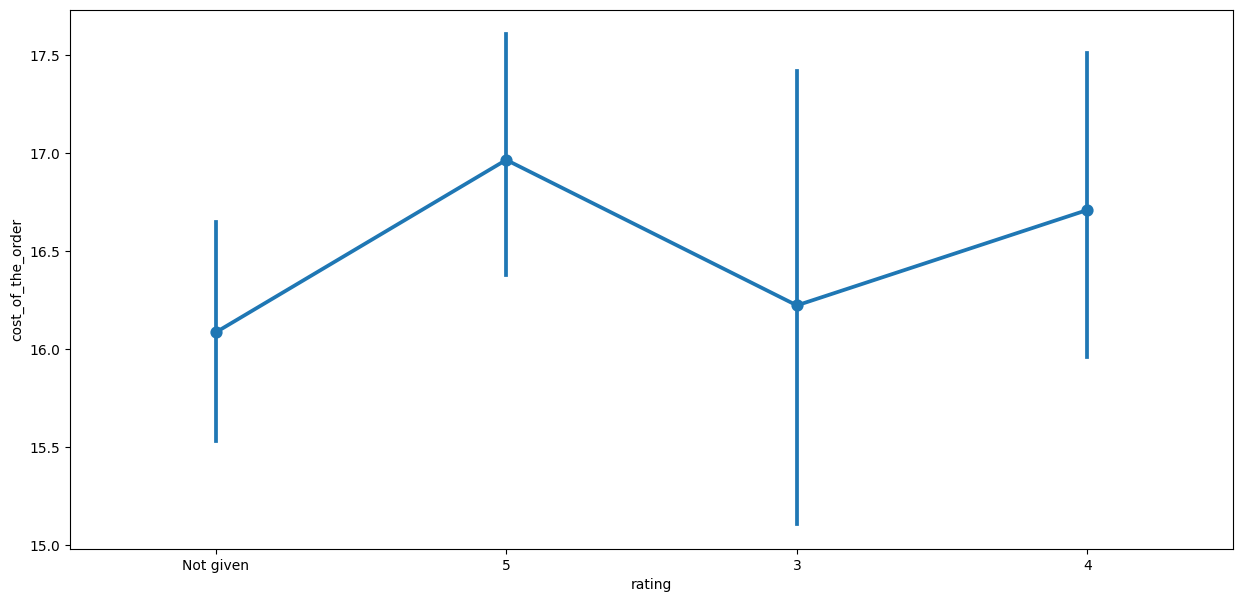

In [35]:
plt.figure(figsize=(15,7))
sns.boxplot(x='rating',y='cost_of_the_order',data=df)
plt.show()

plt.figure(figsize=(15,7))
sns.pointplot(x='rating',y='cost_of_the_order',data=df)
plt.show()


###Observations
* The average cost of order is the highest for the rating of 5 at around $16.8.

* The average cost of order is lower for orders that are not rated and those that have a rating of 3 at around $16.3.
* However, the difference in the average cost of orders among different ratings is small which indicates cost of the orders does not drive the ratings.
* The box plot shows that the median and spread are almost uniform across ratings which again confirms that customers of all cost ranges have provided all types of rating.

## **Correlation among Cost of Order, Food Preparation time and Delivery time**


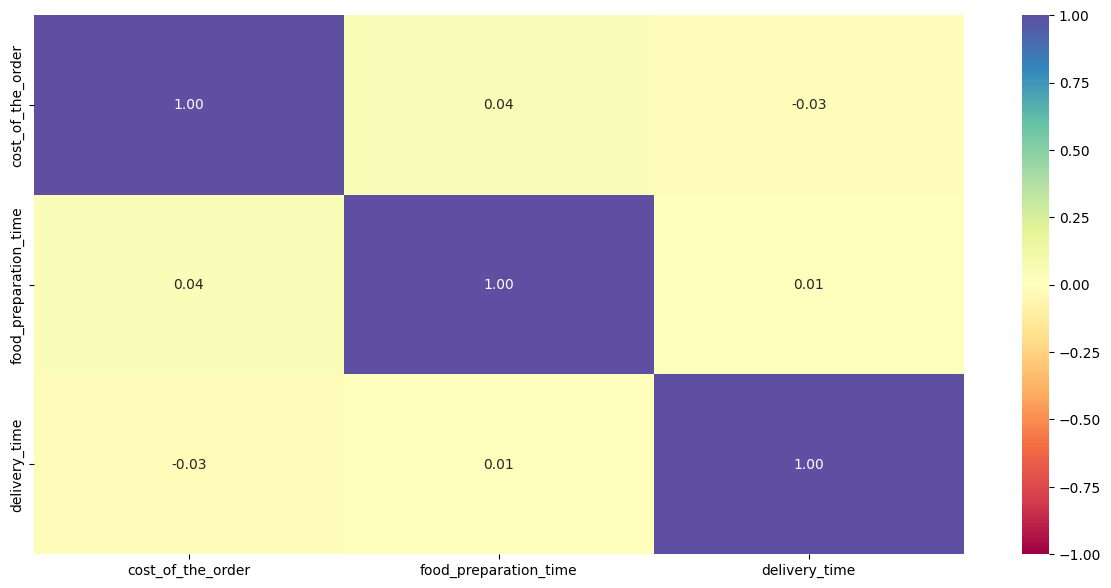

In [36]:
col =['cost_of_the_order','food_preparation_time','delivery_time']
plt.figure(figsize=(15,7))
sns.heatmap(df[col].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

### Observations

The heatmap shows no correlation among cost of order, food preparation time and delivery time.

## **Revenue generated by companies**

In [37]:
revenue = df.groupby('restaurant_name')['cost_of_the_order'].sum().sort_values(ascending=False).head(14)
revenue


,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29


### Observations:
Shake Shack generated the highest revenue of 3579.53 dollars followed by The Meatball Shop at 2145.21 dollars, which is 40% lower than Shake Shack.
Most of the remaining restautants have revenue between 1000-500 dollars indicating a more even spread.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [38]:
#Create new column for rating as float data type and replace 'Not given' values to NaN.
df['rating_float'] = df['rating'].replace('Not given',np.nan)
df['rating_float']= df['rating_float'].astype('float64')

# find the rating count and mean rating for each restaurant using groupby restaurant name

restaurant_rating = df.groupby('restaurant_name')['rating_float'].agg(['count','mean'])
restaurant_rating

# use conditional statement to find the restaurants the satify the criteria
list_of_restaurants = restaurant_rating[(restaurant_rating['count']>50) & (restaurant_rating['mean']>4)]
list_of_restaurants

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:

There are 4 restaurants that fulfill the criteria for the promotional offer.

*   Blue Ribbon Fried Chicken
*   Blue Ribbon Sushi
*   Shake Shack
*   The Meatball Shop

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [39]:
# Write the code
cost_greater_than_20 = df[df['cost_of_the_order']>20].cost_of_the_order.sum()*.25
cost_greater_than_5 = df[(df['cost_of_the_order']>5) & (df['cost_of_the_order']<20)].cost_of_the_order.sum()*.15
net_revenue = cost_greater_than_20 + cost_greater_than_5
net_revenue


np.float64(6166.303)

#### Observations:
The net revenue generated by the company across all orders is around $6166.30.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [40]:
# Write the code here
df.head()
df['total_order_time'] = df['food_preparation_time'] + df['delivery_time']
order_percent = df[df['total_order_time'] > 60].total_order_time.count()*100/len(df)
order_percent


np.float64(10.53740779768177)

#### Observations:
Around 10.5% of the orders take more than 60mins to get delivered from the time the order is placed.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [41]:
# Write the code here
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
The mean delivery time during weekday is 28.34 mins and weekend is 22.47 mins.
The mean delivery time during the weekdays are atleast 6 minutes longer than the mean delivery time during weekends.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  The most popular cuisine is American followed by Japanese and Italian. The least preferred cuisine type is Vietnamese.
*  Restaurants that serve the popular cuisines attract the most number of orders.
*  The number for orders on weekends is almost twice the total number of orders received during weekdays.
*  Average delivery time is during weekdays are longer than weekends indicating potential operational inefficiencies.
* Vietnamese and Korean cuisines have the lowest average order prices and shorter preparation times.
*  Delivery time seems to impact the rating of orders. Orders with the lowest rating seems to have longer average delivery time compared to orders with higher ratings.
* 39% of the orders were not rated, indicating a need to improve the feeback system within the app.




### Recommendations:

1. **Promote Popular Cuisines to boost weekday sales:** Foodhub should introduce special deals and discounts for popular cuisines such as American, Japanese, and Italian to boost sales on weekdays. Highlight restaurants serving these top rated cusines in the app to drive more weekday traffic.

2. **Optimize Operations to reduce weekday delivery time**:  Foodhub must optimize its map routes using real-time traffic data to reduce delivery time. Additionally, increase driver availability during weekdays by offering incentives or surge pay to reduce wait times.

3. **Encourage Customer Feedback** : Foodhub should enhance its feedback system by offering incentives or simplyfying the rating system to encourage more customers to share their order experience.

4. **Improve Customer Satifaction**: The company must prioritize operational changes that reduce delivery delays as it has a correlation with lower customer ratings.

5. **Improve visibilty of less preferred cuisines**: Foodhub can consider marketing campaigns positioning Vietnamese and Korean cuisines as a budget-friendly and quick-delivery options for weekdays.The app can offer bundled deals and discounts for underperforming cuisines to encourage customer trials.


---